## PPO evaluation notebook (Transformer vs MLP vs CNN)

This notebook compares your **three PPO model variants** using **multi-dimensional evaluation metrics**, matching the TA feedback.

### Metrics (multi-dimensional)

- **Performance (reward)**: `eval_mean` (mean episode return during evaluation rollouts)
- **Task success**: `eval_score` (mean apples eaten per episode)
- **Efficiency / training speed (sample efficiency)**:
  - env steps to reach a target success level (e.g. first step where `eval_score >= 0.5`)
  - env steps to reach a target reward level (e.g. first step where `eval_mean >= 0`)
- **Stability**:
  - `eval_std` (std of eval episode returns across rollouts)
  - variability of `eval_score`
- **Behavior profile**: `eval_len` (episode length), helps detect "survive-but-don't-eat" policies

Notes:
- `best_ppo.pt` is saved by maximizing **`eval_mean`** (reward), *not* `eval_score`.
- We parse `logs/log_ppo_*.out` because it includes `eval_score` and `eval_len`.


In [6]:
import os
import re
import glob
import pickle
from dataclasses import dataclass
from typing import Dict, List, Optional, Tuple

import numpy as np
import matplotlib.pyplot as plt

ROOT = os.getcwd()  # run from cs228/final/SnakeDeepQModel
SAVE_DIR = os.path.join(ROOT, "save_models")
LOG_DIR = os.path.join(ROOT, "logs")

plt.rcParams["figure.dpi"] = 120


In [7]:
@dataclass
class RunCurves:
    run_name: str
    group: str  # transformer|mlp|cnn|other
    steps: np.ndarray
    train100: np.ndarray
    eval100: np.ndarray
    eval_mean: np.ndarray
    eval_std: np.ndarray
    eval_score: Optional[np.ndarray] = None
    eval_len: Optional[np.ndarray] = None


def infer_group(run_name: str) -> str:
    s = run_name.lower()
    if "transformer" in s:
        return "transformer"
    if "mlp" in s:
        return "mlp"
    if "cnn" in s:
        return "cnn"
    return "other"


def load_ppo_result_pkl(pkl_path: str) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """Returns steps, train100, eval100, eval_means, eval_stds."""
    with open(pkl_path, "rb") as f:
        d = pickle.load(f)
    results = np.asarray(d.get("results", []), dtype=np.float32)  # (K,3): steps, train100, eval100
    steps = results[:, 0].astype(np.int64)
    train100 = results[:, 1]
    eval100 = results[:, 2]
    eval_means = np.asarray(d.get("eval_means", []), dtype=np.float32)
    eval_stds = np.asarray(d.get("eval_stds", []), dtype=np.float32)
    return steps, train100, eval100, eval_means, eval_stds


def parse_log_file(log_path: str) -> Optional[RunCurves]:
    """Parse `logs/log_ppo_*.out` for run_name + eval_score/eval_len curves."""
    txt = open(log_path, "r", encoding="utf-8", errors="ignore").read()

    m = re.search(r"^run_name:\s*(\S+)\s*$", txt, flags=re.MULTILINE)
    if not m:
        return None
    run_name = m.group(1)
    group = infer_group(run_name)

    # Metric lines (all floats are simple decimals in these logs)
    pat = re.compile(
        r"^\[Episode\s+\d+\]\s+\[steps\s+(?P<steps>\d+)\]\s+"
        r"train100=(?P<train100>-?\d+(?:\.\d+)?)\s+"
        r"eval_mean=(?P<eval_mean>-?\d+(?:\.\d+)?)\s+\(std=(?P<eval_std>-?\d+(?:\.\d+)?)\)\s+"
        r"eval_score=(?P<eval_score>-?\d+(?:\.\d+)?)\s+\(std=(?P<eval_score_std>-?\d+(?:\.\d+)?)\)\s+"
        r"eval_len=(?P<eval_len>-?\d+(?:\.\d+)?)\s+\(std=(?P<eval_len_std>-?\d+(?:\.\d+)?)\)\s+"
        r"eval100=(?P<eval100>-?\d+(?:\.\d+)?)",
        flags=re.MULTILINE,
    )

    rows = [mm.groupdict() for mm in pat.finditer(txt)]
    if not rows:
        return None

    steps = np.array([int(r["steps"]) for r in rows], dtype=np.int64)
    train100 = np.array([float(r["train100"]) for r in rows], dtype=np.float32)
    eval100 = np.array([float(r["eval100"]) for r in rows], dtype=np.float32)
    eval_mean = np.array([float(r["eval_mean"]) for r in rows], dtype=np.float32)
    eval_std = np.array([float(r["eval_std"]) for r in rows], dtype=np.float32)
    eval_score = np.array([float(r["eval_score"]) for r in rows], dtype=np.float32)
    eval_len = np.array([float(r["eval_len"]) for r in rows], dtype=np.float32)

    return RunCurves(
        run_name=run_name,
        group=group,
        steps=steps,
        train100=train100,
        eval100=eval100,
        eval_mean=eval_mean,
        eval_std=eval_std,
        eval_score=eval_score,
        eval_len=eval_len,
    )


def try_attach_pkl(curves: RunCurves) -> RunCurves:
    """If save_models/<run_name>/PPO_result.pkl exists, use it for eval_mean/std/train100/eval100.

    (Logs can be truncated; pkl is the canonical curve source for reward-based metrics.)
    """
    pkl_path = os.path.join(SAVE_DIR, curves.run_name, "PPO_result.pkl")
    if not os.path.exists(pkl_path):
        return curves

    steps, train100, eval100, eval_means, eval_stds = load_ppo_result_pkl(pkl_path)
    return RunCurves(
        run_name=curves.run_name,
        group=curves.group,
        steps=steps,
        train100=train100,
        eval100=eval100,
        eval_mean=eval_means,
        eval_std=eval_stds,
        eval_score=curves.eval_score,
        eval_len=curves.eval_len,
    )


def first_step_reaching(steps: np.ndarray, y: np.ndarray, threshold: float) -> Optional[int]:
    idx = np.where(y >= threshold)[0]
    if idx.size == 0:
        return None
    return int(steps[int(idx[0])])


In [8]:
# Load ONLY the 3 runs you want to compare
# (transformer, mlp, cnn)
log_paths = [
    os.path.join(LOG_DIR, "log_ppo_245084.out"),  # transformer
    os.path.join(LOG_DIR, "log_ppo_245093.out"),  # mlp
    os.path.join(LOG_DIR, "log_ppo_245094.out"),  # cnn
]

missing = [p for p in log_paths if not os.path.exists(p)]
if missing:
    raise FileNotFoundError("Missing log files:\n" + "\n".join(missing))

runs: List[RunCurves] = []
for lp in log_paths:
    rc = parse_log_file(lp)
    if rc is None:
        raise RuntimeError(f"Failed to parse run_name/metrics from: {lp}")
    rc = try_attach_pkl(rc)
    runs.append(rc)

print(f"found runs: {len(runs)}")
for lp, r in zip(log_paths, runs):
    print(f"- {r.group:11s} {r.run_name} (from {os.path.basename(lp)})")


found runs: 3
- transformer ppo_snake_transformer_0307_152337_seed0 (from log_ppo_245084.out)
- mlp         ppo_snake_mlp_flat_0307_155549_seed0 (from log_ppo_245093.out)
- cnn         ppo_snake_cnn_grid_0307_155553_seed0 (from log_ppo_245094.out)


In [9]:
# Summary table (multi-dimensional)

def summarize_run(r: RunCurves) -> Dict[str, object]:
    best_eval_mean = float(np.max(r.eval_mean)) if r.eval_mean.size else float("nan")
    best_eval_mean_step = int(r.steps[int(np.argmax(r.eval_mean))]) if r.eval_mean.size else None

    out = {
        "group": r.group,
        "run_name": r.run_name,
        "final_eval_mean": float(r.eval_mean[-1]) if r.eval_mean.size else float("nan"),
        "best_eval_mean": best_eval_mean,
        "best_eval_mean_step": best_eval_mean_step,
        "mean_eval_std_last10": float(np.mean(r.eval_std[-10:])) if r.eval_std.size >= 10 else float(np.mean(r.eval_std)) if r.eval_std.size else float("nan"),
    }

    if r.eval_score is not None and r.eval_score.size:
        out.update({
            "final_eval_score": float(r.eval_score[-1]),
            "best_eval_score": float(np.max(r.eval_score)),
            "steps_to_score>=0.5": first_step_reaching(r.steps[: r.eval_score.size], r.eval_score, 0.5),
            "steps_to_score>=1.0": first_step_reaching(r.steps[: r.eval_score.size], r.eval_score, 1.0),
            "P(score>0)": float(np.mean(r.eval_score > 0.0)),
        })
    else:
        out.update({
            "final_eval_score": float("nan"),
            "best_eval_score": float("nan"),
            "steps_to_score>=0.5": None,
            "steps_to_score>=1.0": None,
            "P(score>0)": float("nan"),
        })

    out["steps_to_eval_mean>=0"] = first_step_reaching(r.steps, r.eval_mean, 0.0)

    if r.eval_len is not None and r.eval_len.size:
        out["final_eval_len"] = float(r.eval_len[-1])
    else:
        out["final_eval_len"] = float("nan")

    return out

summary = [summarize_run(r) for r in runs]

# Print a compact view (no pandas dependency)
cols = [
    "group",
    "run_name",
    "best_eval_mean",
    "steps_to_eval_mean>=0",
    "best_eval_score",
    "steps_to_score>=0.5",
    "steps_to_score>=1.0",
    "mean_eval_std_last10",
]

print("\t".join(cols))
for row in summary:
    print("\t".join(str(row.get(c, "")) for c in cols))


group	run_name	best_eval_mean	steps_to_eval_mean>=0	best_eval_score	steps_to_score>=0.5	steps_to_score>=1.0	mean_eval_std_last10
transformer	ppo_snake_transformer_0307_152337_seed0	44.75300216674805	512	4.599999904632568	2816	45056	13.674993515014648
mlp	ppo_snake_mlp_flat_0307_155549_seed0	49.28150177001953	1280	5.0	9216	35584	24.196979522705078
cnn	ppo_snake_cnn_grid_0307_155553_seed0	46.03200149536133	256	4.699999809265137	32256	102656	20.395029067993164


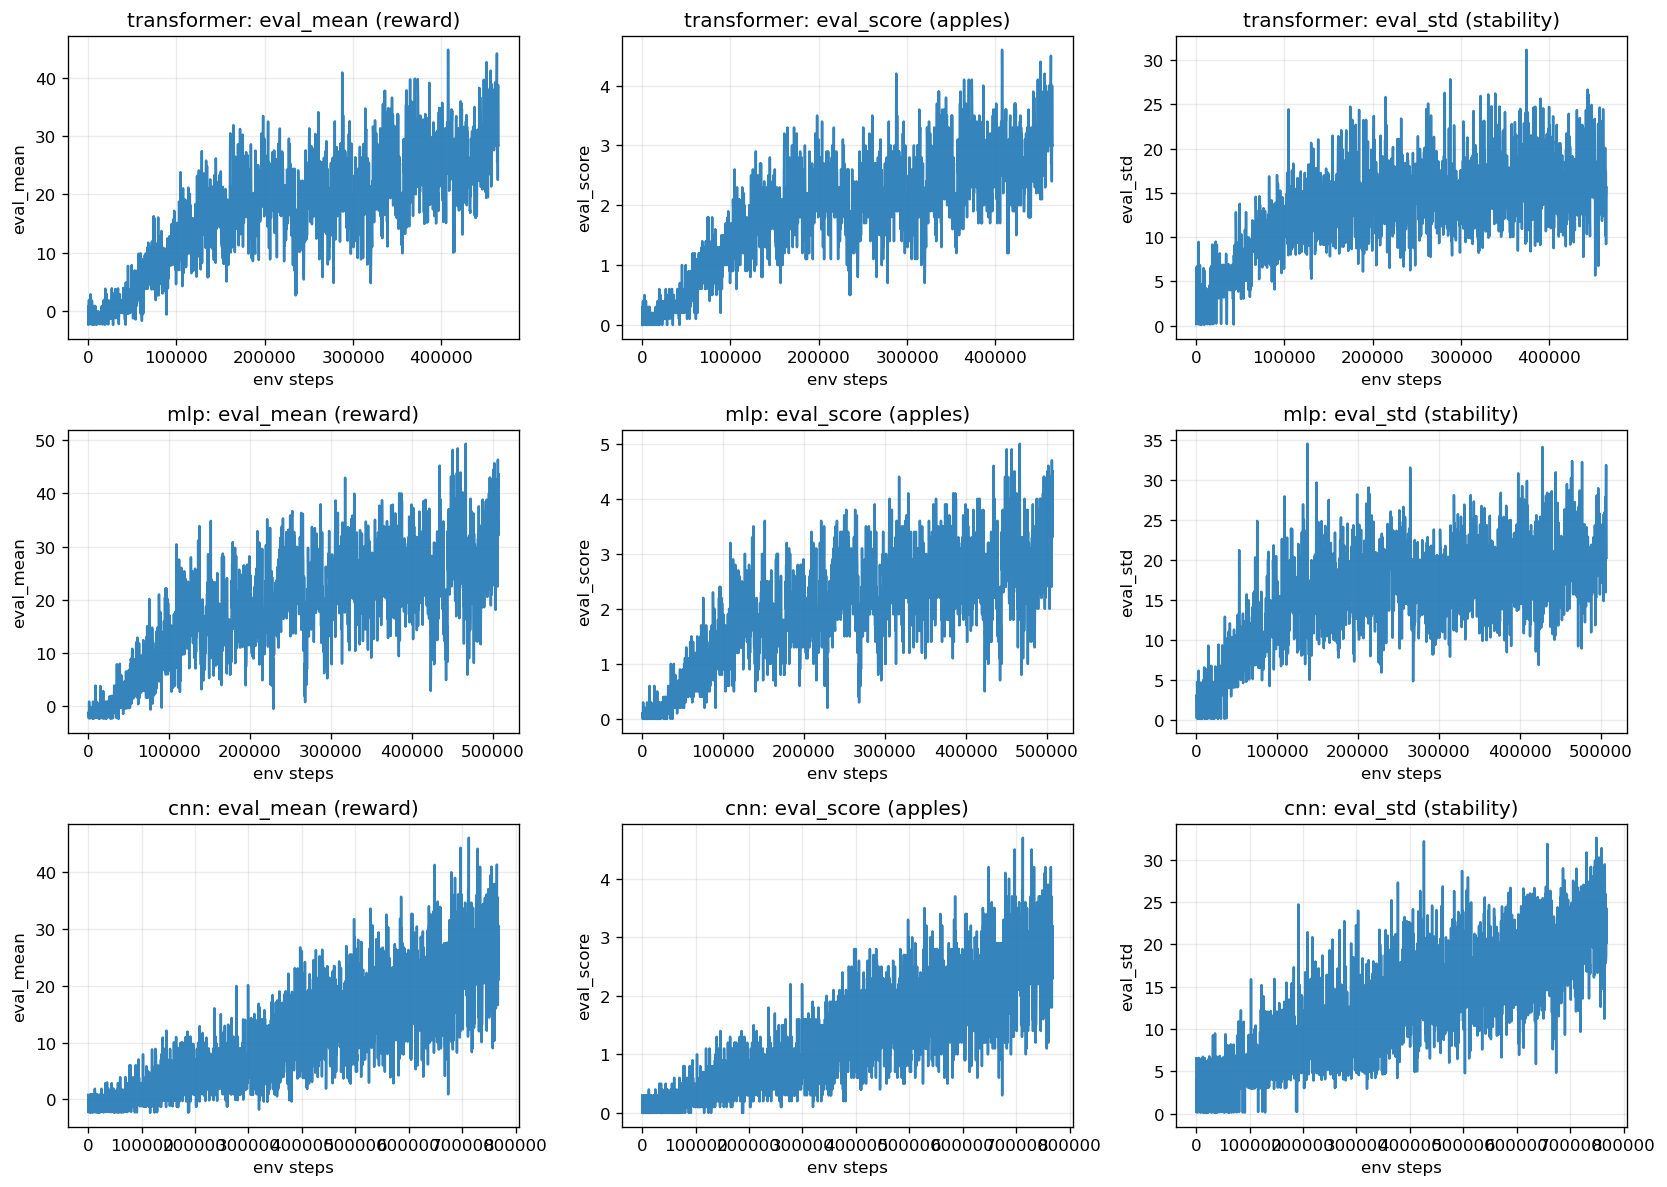

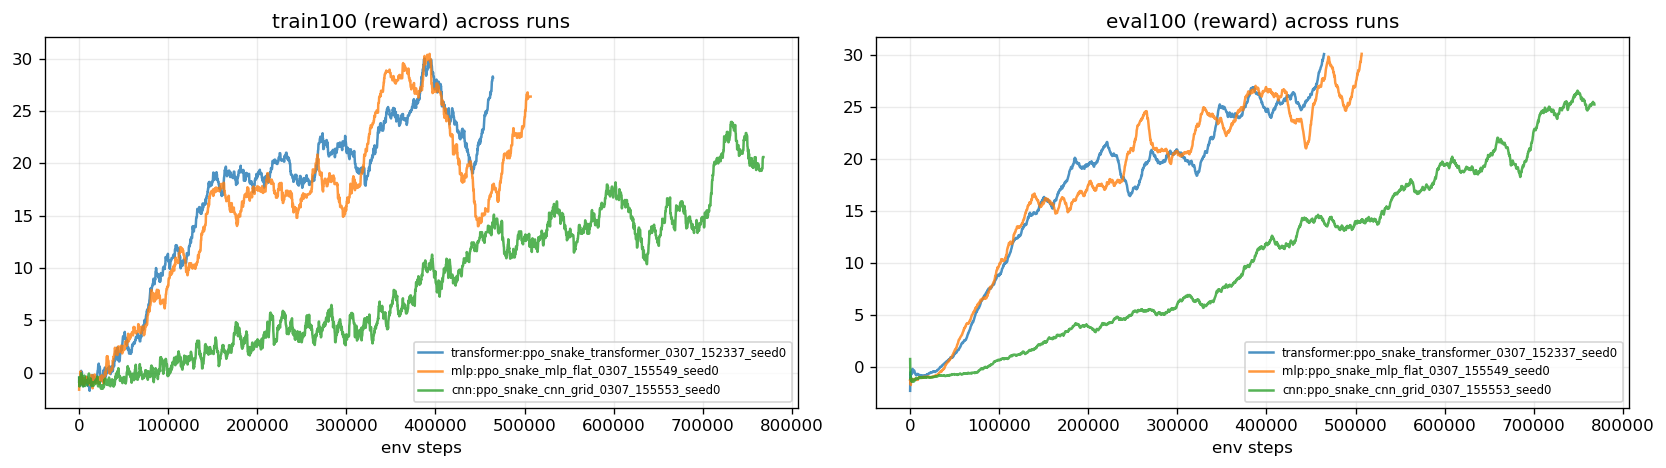

In [10]:
# Plots: learning curves by env steps

def plot_group_curves(runs: List[RunCurves], group: str, ax, y: str, title: str, ylabel: str):
    rs = [r for r in runs if r.group == group]
    if not rs:
        ax.set_title(f"{title} (no runs)")
        return

    for r in rs:
        yy = getattr(r, y)
        xx = r.steps[: yy.size]
        ax.plot(xx, yy, alpha=0.9, linewidth=1.5, label=r.run_name)

    ax.set_title(title)
    ax.set_xlabel("env steps")
    ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.25)


groups = ["transformer", "mlp", "cnn"]

fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(14, 10), sharex=False)

for i, g in enumerate(groups):
    plot_group_curves(runs, g, axes[i, 0], "eval_mean", f"{g}: eval_mean (reward)", "eval_mean")
    plot_group_curves(runs, g, axes[i, 1], "eval_score", f"{g}: eval_score (apples)", "eval_score")
    plot_group_curves(runs, g, axes[i, 2], "eval_std", f"{g}: eval_std (stability)", "eval_std")

plt.tight_layout()
plt.show()

# Optional: compare train100 vs eval100 (reward-based)
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 4))
for r in runs:
    axes[0].plot(r.steps, r.train100, alpha=0.8, label=f"{r.group}:{r.run_name}")
    axes[1].plot(r.steps, r.eval100, alpha=0.8, label=f"{r.group}:{r.run_name}")
axes[0].set_title("train100 (reward) across runs")
axes[1].set_title("eval100 (reward) across runs")
for ax in axes:
    ax.set_xlabel("env steps")
    ax.grid(True, alpha=0.25)
    ax.legend(fontsize=7)
plt.tight_layout()
plt.show()
